In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Load the dataset
file_path = "/content/EastWestAirlines(1).xlsx"

df = pd.read_excel("/content/EastWestAirlines.xlsx", sheet_name="data")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (3999, 12)

First 5 Rows:


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB

Statistical Summary:


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


Missing Values:
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

Duplicate Rows: 0

Features Used for Clustering:
['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']


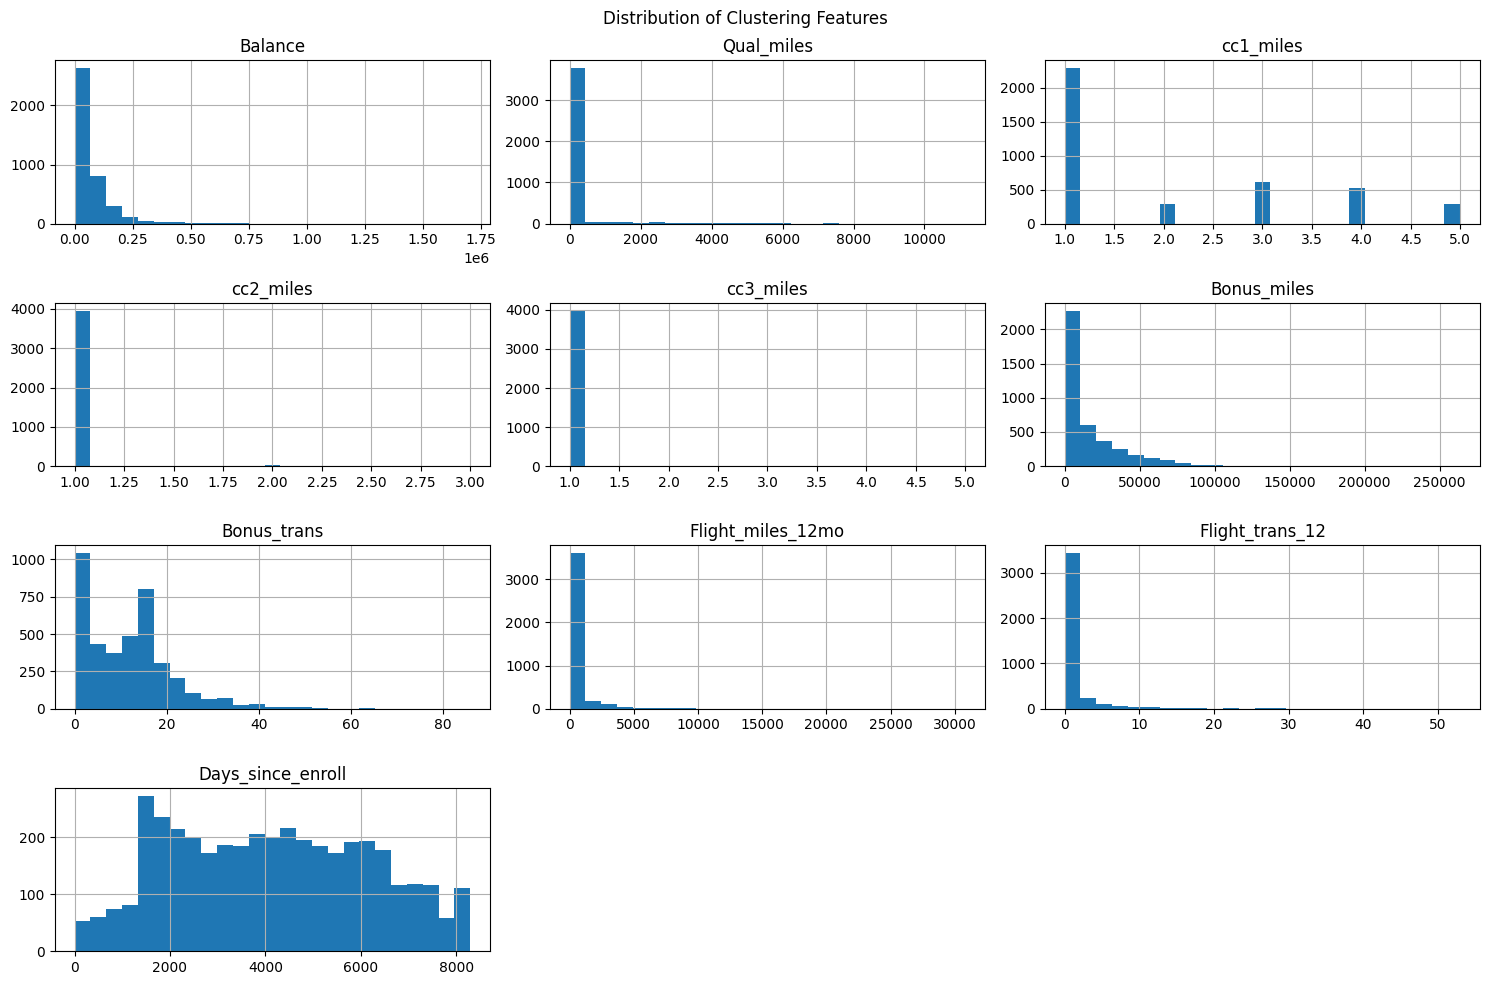

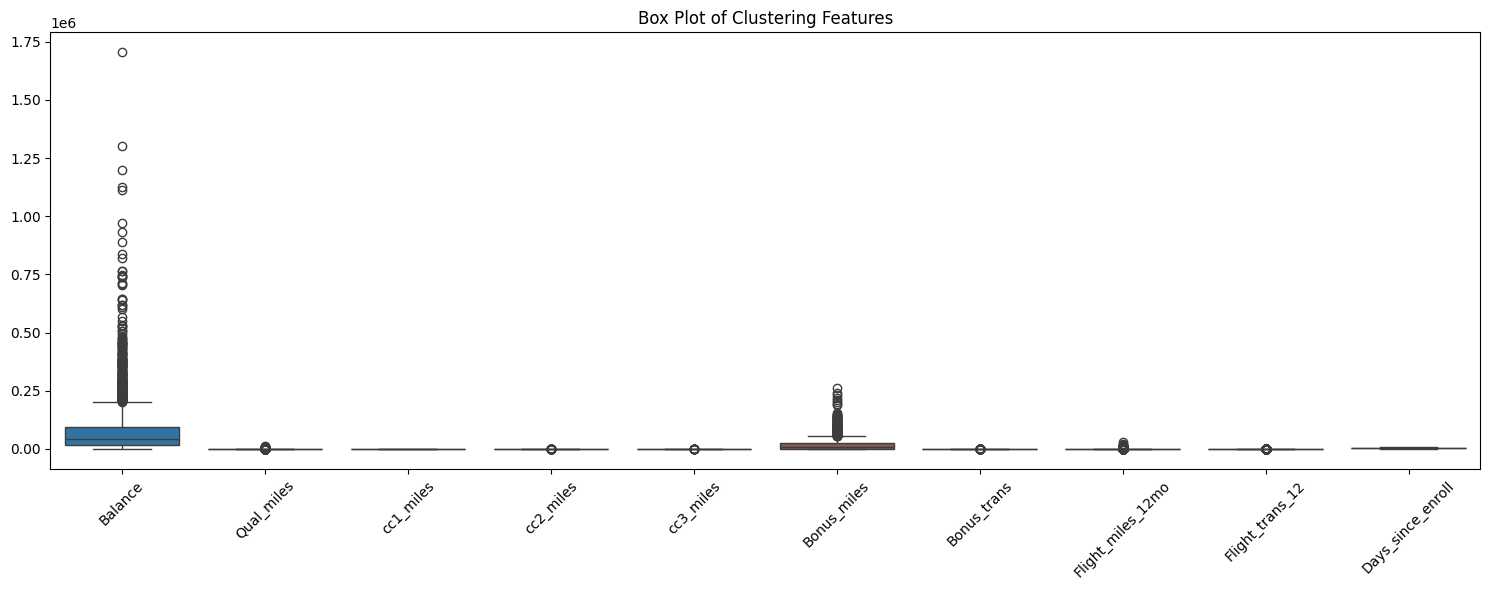

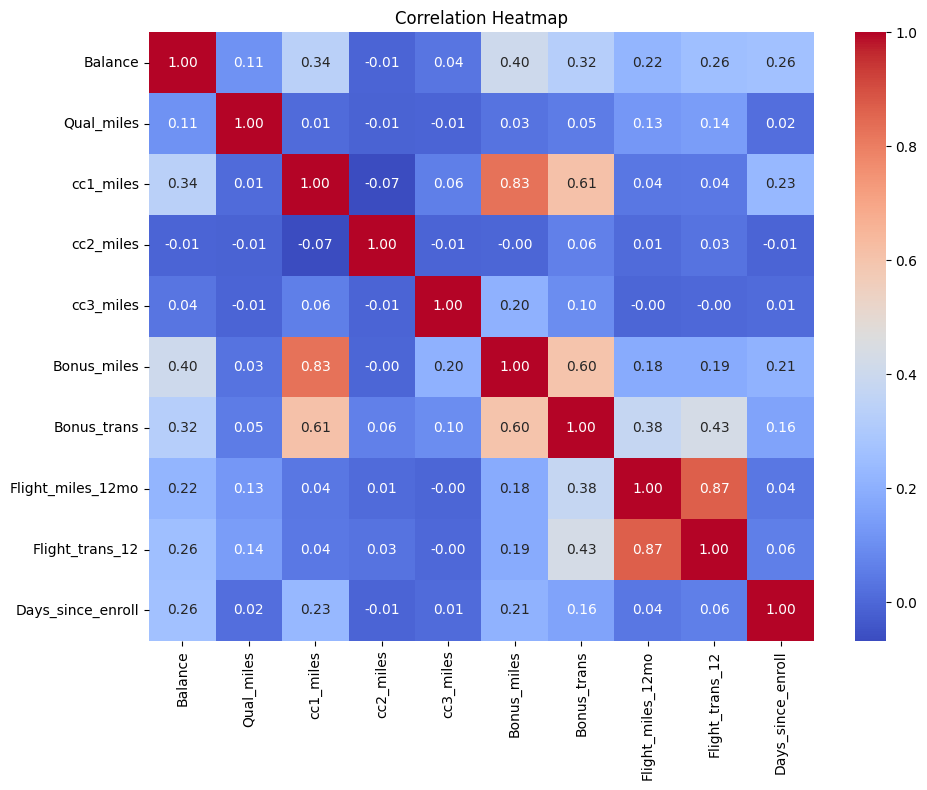

In [65]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Features used for clustering
features = [
    'Balance',
    'Qual_miles',
    'cc1_miles',
    'cc2_miles',
    'cc3_miles',
    'Bonus_miles',
    'Bonus_trans',
    'Flight_miles_12mo',
    'Flight_trans_12',
    'Days_since_enroll'
]

X = df[features].copy()

print("\nFeatures Used for Clustering:")
print(features)

# -----------------------------
# Histograms
# -----------------------------
X.hist(
    figsize=(15, 10),
    bins=25
)

plt.suptitle(
    "Distribution of Clustering Features"
)

plt.tight_layout()
plt.show()

# -----------------------------
# Boxplots
# -----------------------------
plt.figure(figsize=(15, 6))

sns.boxplot(data=X)

plt.title(
    "Box Plot of Clustering Features"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# -----------------------------
# Correlation Heatmap
# -----------------------------
plt.figure(figsize=(10, 8))

sns.heatmap(
    X.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.tight_layout()
plt.show()

In [66]:
# Create a copy for outlier treatment
X_clean = X.copy()

# IQR-based capping
for column in X_clean.columns:

    Q1 = X_clean[column].quantile(0.25)
    Q3 = X_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    X_clean[column] = X_clean[column].clip(
        lower_limit,
        upper_limit
    )

print("Outlier treatment completed.")

# Standardization
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_clean)

print("\nScaled Data Shape:", X_scaled.shape)

print("\nMean after scaling:")
print(X_scaled.mean(axis=0).round(2))

print("\nStandard deviation after scaling:")
print(X_scaled.std(axis=0).round(2))

Outlier treatment completed.

Scaled Data Shape: (3999, 10)

Mean after scaling:
[-0.  0.  0.  0.  0. -0.  0. -0.  0.  0.]

Standard deviation after scaling:
[1. 0. 1. 0. 0. 1. 1. 1. 1. 1.]


In [67]:
# Select number of clusters based on the Elbow Curve
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

# Cluster counts
print("K-Means Cluster Counts:")
print(
    pd.Series(kmeans_labels)
    .value_counts()
    .sort_index()
)

# Silhouette Score
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print(
    "\nK-Means Silhouette Score:",
    round(kmeans_silhouette, 4)
)

K-Means Cluster Counts:
0    1901
1     396
2    1064
3     638
Name: count, dtype: int64

K-Means Silhouette Score: 0.3412


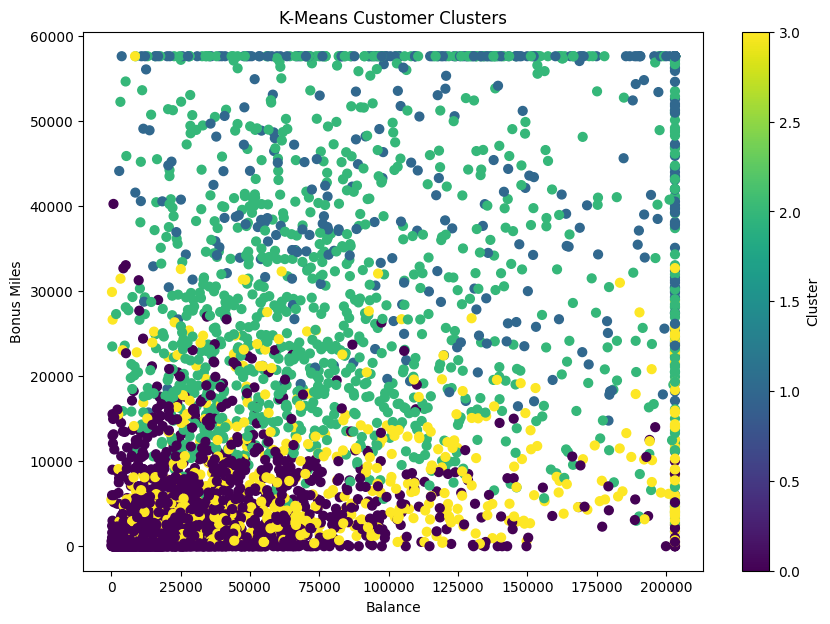

In [68]:
# Visualize using two important features
plt.figure(figsize=(10, 7))

plt.scatter(
    X_clean['Balance'],
    X_clean['Bonus_miles'],
    c=kmeans_labels,
    cmap='viridis',
    s=40
)

plt.xlabel("Balance")
plt.ylabel("Bonus Miles")

plt.title(
    "K-Means Customer Clusters"
)

plt.colorbar(
    label="Cluster"
)

plt.show()

In [69]:
# -----------------------------
# Experiment with DBSCAN
# -----------------------------

eps_values = [0.3, 0.5, 0.7, 0.9, 1.1]

print("DBSCAN Parameter Experiment\n")

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(
        X_scaled
    )

    n_clusters = len(
        set(labels) - {-1}
    )

    noise_points = sum(
        labels == -1
    )

    print(
        f"eps = {eps} | "
        f"Clusters = {n_clusters} | "
        f"Noise = {noise_points}"
    )

DBSCAN Parameter Experiment

eps = 0.3 | Clusters = 24 | Noise = 2441
eps = 0.5 | Clusters = 30 | Noise = 1393
eps = 0.7 | Clusters = 23 | Noise = 789
eps = 0.9 | Clusters = 10 | Noise = 369
eps = 1.1 | Clusters = 2 | Noise = 140


In [70]:
# -----------------------------
# Final DBSCAN
# -----------------------------

best_eps = 0.7

dbscan = DBSCAN(
    eps=best_eps,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)

print("\nDBSCAN Cluster Counts:")

print(
    pd.Series(
        dbscan_labels
    ).value_counts().sort_index()
)

# -----------------------------
# Silhouette Score
# -----------------------------

valid_points = dbscan_labels != -1

unique_clusters = set(
    dbscan_labels[valid_points]
)

if (
    len(unique_clusters) >= 2
    and valid_points.sum() > 1
):

    dbscan_silhouette = silhouette_score(
        X_scaled[valid_points],
        dbscan_labels[valid_points]
    )

    print(
        "\nDBSCAN Silhouette Score:",
        round(dbscan_silhouette, 4)
    )

else:

    dbscan_silhouette = np.nan

    print(
        "\nSilhouette Score cannot be calculated because DBSCAN "
        "did not produce at least two valid clusters."
    )


DBSCAN Cluster Counts:
-1      789
 0     1555
 1      150
 2      200
 3      124
 4      281
 5      409
 6      337
 7        5
 8        5
 9       30
 10      25
 11       5
 12       4
 13       5
 14      16
 15      11
 16       3
 17       5
 18      17
 19       5
 20       5
 21       5
 22       8
Name: count, dtype: int64

DBSCAN Silhouette Score: 0.0985


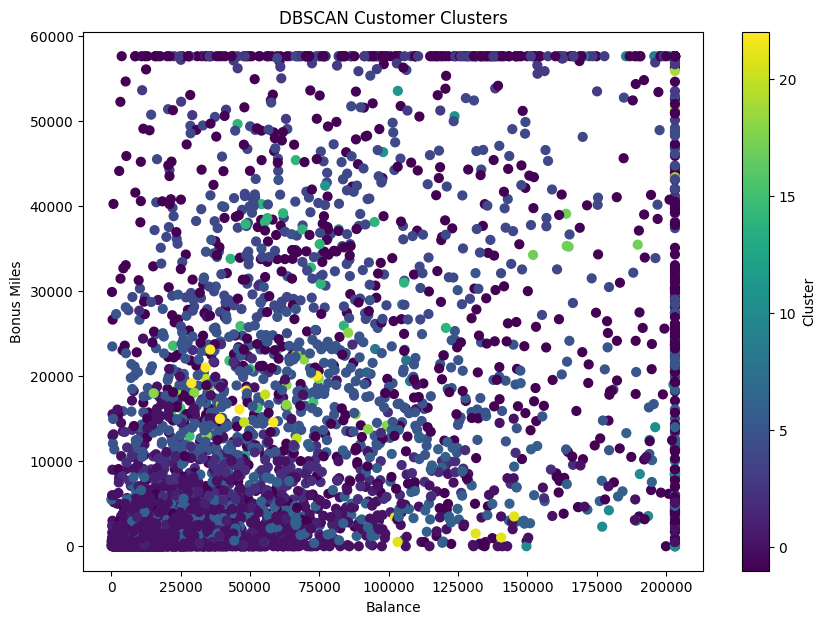

In [71]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_clean['Balance'],
    X_clean['Bonus_miles'],
    c=dbscan_labels,
    cmap='viridis',
    s=40
)

plt.xlabel("Balance")
plt.ylabel("Bonus Miles")

plt.title(
    "DBSCAN Customer Clusters"
)

plt.colorbar(
    label="Cluster"
)

plt.show()

# Cluster Analysis and Interpretation

The clusters created by K-Means and DBSCAN represent different groups of
airline customers based on their mileage, balance, bonus activity, and flight
behavior.

Customers in clusters with higher average Balance, Bonus_miles, or
Flight_miles_12mo can be interpreted as more active or higher-value customers.

Clusters with lower activity values may represent less-active customers.

DBSCAN may additionally identify noise points, represented by cluster `-1`.
These observations do not belong to a sufficiently dense cluster.

# K-Means vs DBSCAN

K-Means requires the number of clusters to be specified and works well when
clusters are relatively compact and separated.

DBSCAN does not require the number of clusters in advance and can identify
noise and irregularly shaped clusters. However, its results are sensitive to
the selection of `eps` and `min_samples`.

The Silhouette Score is used to compare clustering quality. A higher
Silhouette Score indicates better-defined and better-separated clusters.

# Conclusion

In this assignment, customer segmentation was performed using K-Means and
DBSCAN clustering algorithms on the EastWest Airlines dataset.

The dataset was explored using statistical summaries, histograms, box plots,
and a correlation heatmap. Missing values and duplicate records were checked,
and extreme values were treated using IQR-based capping.

The numerical features were standardized before applying the clustering
algorithms because both K-Means and DBSCAN are distance-based methods.

For K-Means, the Elbow Method was used to determine an appropriate number of
clusters. DBSCAN was evaluated using different values of `eps` and a fixed
`min_samples` value.

The Silhouette Score was used as an internal clustering evaluation metric.
The clustering algorithm with the higher Silhouette Score provides better
separation for this dataset.

The resulting customer segments can be useful for customer profiling,
targeted marketing, loyalty programs, and identifying high-value airline
customers.

In [72]:
# Add cluster labels to the dataset
df_result = df.copy()

df_result["KMeans_Cluster"] = kmeans_labels
df_result["DBSCAN_Cluster"] = dbscan_labels

# -----------------------------
# K-Means Cluster Characteristics
# -----------------------------

print("K-Means Cluster Characteristics:\n")

display(
    df_result.groupby(
        "KMeans_Cluster"
    )[features].mean().round(2)
)

# -----------------------------
# DBSCAN Cluster Characteristics
# -----------------------------

print("\nDBSCAN Cluster Characteristics:\n")

display(
    df_result.groupby(
        "DBSCAN_Cluster"
    )[features].mean().round(2)
)

# -----------------------------
# Performance Comparison
# -----------------------------

comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "DBSCAN"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        dbscan_silhouette
    ]
})

print("\nClustering Performance Comparison:")

display(comparison)

K-Means Cluster Characteristics:



,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
KMeans_Cluster,,,,,,,,,,
0,32572.52,77.85,1.13,1.02,1.00,3455.16,5.94,12.19,0.06,3589.12
1,175886.81,319.23,4.06,1.02,1.05,55968.87,25.97,1953.31,5.66,5097.72
2,98786.53,95.66,3.48,1.00,1.03,32701.62,17.00,25.21,0.12,4715.00
3,90362.55,313.67,1.22,1.02,1.00,7893.08,10.55,1592.86,4.71,4093.65



DBSCAN Cluster Characteristics:



,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
DBSCAN_Cluster,,,,,,,,,,
-1,129524.57,266.95,2.96,1.02,1.05,34830.93,21.09,1286.44,3.93,4671.56
0,28623.88,67.62,1.00,1.02,1.00,2489.97,5.23,0.00,0.00,3575.18
1,33449.40,131.67,1.00,1.01,1.00,2615.31,4.89,319.30,1.00,3583.53
2,52069.10,71.48,2.00,1.00,1.00,9303.64,13.16,0.00,0.00,4137.34
3,147493.15,47.02,5.00,1.00,1.05,70461.34,16.93,0.00,0.00,5089.77
4,94914.78,63.94,4.00,1.00,1.01,38067.80,16.41,0.00,0.00,4771.12
5,73565.48,93.42,3.00,1.00,1.00,18575.51,14.55,0.00,0.00,4320.36
6,83914.78,423.92,1.00,1.01,1.00,5095.90,8.32,1894.60,5.49,3872.06
7,60218.60,0.00,1.00,1.00,1.00,3008.60,10.60,212.40,1.00,6840.00



Clustering Performance Comparison:


,Algorithm,Silhouette Score
0,K-Means,0.341178
1,DBSCAN,0.098506
